In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
from sklearn.datasets import load_iris
x=load_iris()
df = pd.DataFrame(x.data, columns=x.feature_names)
df['target'] = x.target

In [21]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [22]:
X=df.copy()

In [23]:
X.drop("target",inplace=True,axis=1)

In [24]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [25]:
y = df["target"]


In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [27]:
df_t=scaler.fit_transform(X)

In [28]:
df_t

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train
X_test_scaled = scaler.transform(X_test)        # transform test

In [32]:
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

LogisticRegression()

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred0 = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred0))
print("\nClassification Report:\n", classification_report(y_test, y_pred0))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [34]:
cov_mat=np.cov(df_t.T)

In [35]:
cov_mat

array([[ 1.00671141, -0.11835884,  0.87760447,  0.82343066],
       [-0.11835884,  1.00671141, -0.43131554, -0.36858315],
       [ 0.87760447, -0.43131554,  1.00671141,  0.96932762],
       [ 0.82343066, -0.36858315,  0.96932762,  1.00671141]])

In [36]:
eigenvalues,eigenvectors=np.linalg.eig(cov_mat)

In [37]:
eigenvalues

array([2.93808505, 0.9201649 , 0.14774182, 0.02085386])

In [38]:
eigenvectors

array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
       [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
       [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
       [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]])

In [39]:
from sklearn.decomposition import PCA

In [40]:
pca=PCA()

In [41]:
pca.fit(df_t)

PCA()

In [42]:
explained_variance=pca.explained_variance_ratio_

In [43]:
explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

Text(0, 0.5, 'Cumulative explained variance')

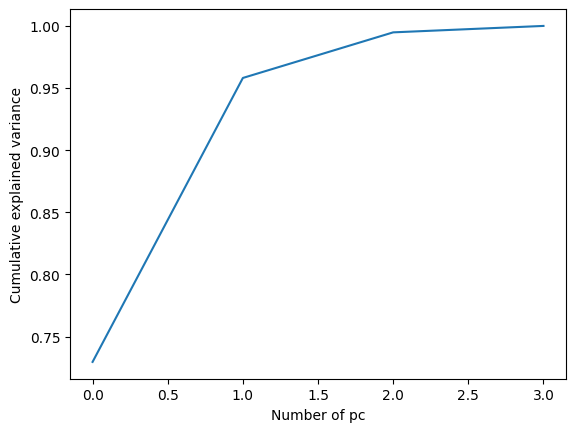

In [44]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of pc")
plt.ylabel("Cumulative explained variance")

WITH ONLY 1 PCA


In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled = scaler.transform(X_test)

In [46]:
pca = PCA(n_components=1)
X_train_pca1 = pca.fit_transform(X_train_scaled)  # fit only on train
X_test_pca1 = pca.transform(X_test_scaled)

In [47]:
X_test_pca1

array([[ 0.67946575],
       [-1.85948524],
       [ 3.37418698],
       [ 0.71543345],
       [ 1.30528623],
       [-1.79741679],
       [ 0.0118878 ],
       [ 1.96579214],
       [ 1.26604398],
       [ 0.28394154],
       [ 1.42644878],
       [-2.1930845 ],
       [-2.01266056],
       [-2.15728158],
       [-2.30465802],
       [ 0.80430783],
       [ 1.93224297],
       [ 0.20360019],
       [ 0.43591001],
       [ 1.92370994],
       [-2.23522568],
       [ 1.07775448],
       [-2.01634009],
       [ 1.84823852],
       [ 2.37942447],
       [ 1.9336523 ],
       [ 2.05969213],
       [ 2.10902509],
       [-2.04214167],
       [-2.11151503]])

In [48]:
cov_matr=np.cov(X_test_pca1.T)
cov_matr

array(3.24809905)

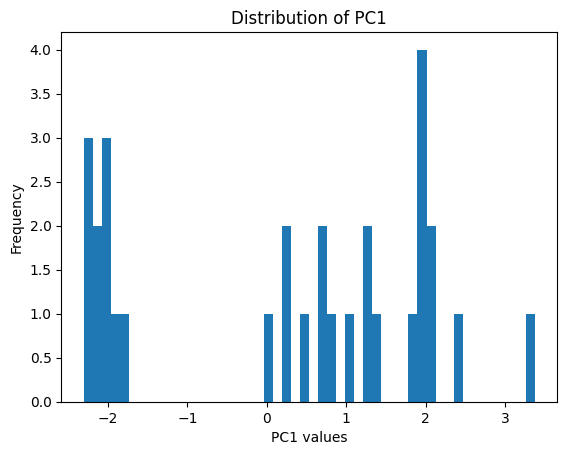

In [49]:
import matplotlib.pyplot as plt

plt.hist(X_test_pca1, bins=50)
plt.title("Distribution of PC1")
plt.xlabel("PC1 values")
plt.ylabel("Frequency")
plt.show()


In [50]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_pca1, y_train)


LogisticRegression()

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred1 = clf.predict(X_test_pca1)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


Accuracy: 0.9

Confusion Matrix:
 [[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



PCA WITH 2 COMPONENTS


In [52]:
pca = PCA(n_components=2)
X_train_pca2 = pca.fit_transform(X_train_scaled)  # fit only on train
X_test_pca2 = pca.transform(X_test_scaled)

In [53]:
X_test_pca2

array([[ 0.67946575, -0.38500577],
       [-1.85948524,  1.36754843],
       [ 3.37418698,  0.08283354],
       [ 0.71543345, -0.20586539],
       [ 1.30528623, -0.03401018],
       [-1.79741679,  0.40889955],
       [ 0.0118878 , -0.4238331 ],
       [ 1.96579214,  0.70535798],
       [ 1.26604398, -1.54750123],
       [ 0.28394154, -0.74331181],
       [ 1.42644878,  0.69591052],
       [-2.1930845 , -0.72356615],
       [-2.01266056,  0.6433383 ],
       [-2.15728158, -0.46935776],
       [-2.30465802,  1.0789989 ],
       [ 0.80430783,  0.76880417],
       [ 1.93224297,  0.31011137],
       [ 0.20360019, -1.25723962],
       [ 0.43591001, -0.57019488],
       [ 1.92370994, -0.15063038],
       [-2.23522568, -0.35016414],
       [ 1.07775448,  0.07612298],
       [-2.01634009,  0.21944905],
       [ 1.84823852, -0.15864072],
       [ 2.37942447,  2.61130874],
       [ 1.9336523 ,  0.40597386],
       [ 2.05969213, -0.65299842],
       [ 2.10902509,  0.87296387],
       [-2.04214167,

In [54]:
cov_matr=np.cov(X_test_pca2.T)
cov_matr

array([[3.24809905, 0.2005675 ],
       [0.2005675 , 0.70183313]])

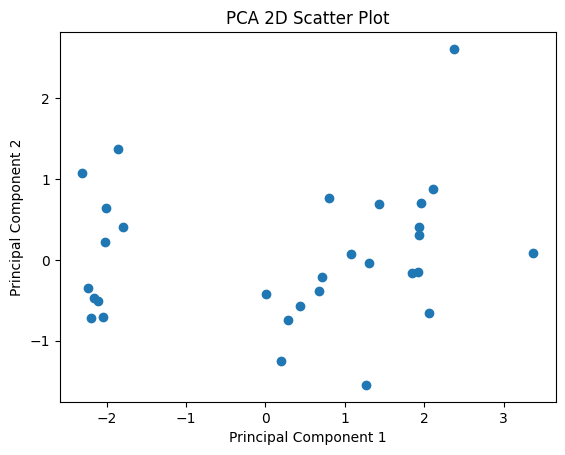

In [55]:
plt.scatter(X_test_pca2[:,0], X_test_pca2[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Scatter Plot")
plt.show()

In [56]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_pca2, y_train)


LogisticRegression()

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred2 = clf.predict(X_test_pca2)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("\nClassification Report:\n", classification_report(y_test, y_pred2))


Accuracy: 0.9

Confusion Matrix:
 [[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



PCA WITH 3 COMPONENTS

In [58]:
pca = PCA(n_components=3)
X_train_pca3 = pca.fit_transform(X_train_scaled)  # fit only on train
X_test_pca3 = pca.transform(X_test_scaled)

In [59]:
X_test_pca3

array([[ 0.67946575, -0.38500577,  0.31273981],
       [-1.85948524,  1.36754843,  0.38692067],
       [ 3.37418698,  0.08283354,  0.71499482],
       [ 0.71543345, -0.20586539, -0.07012633],
       [ 1.30528623, -0.03401018,  0.74545699],
       [-1.79741679,  0.40889955,  0.28936205],
       [ 0.0118878 , -0.4238331 , -0.1768464 ],
       [ 1.96579214,  0.70535798, -0.12722753],
       [ 1.26604398, -1.54750123,  0.51070688],
       [ 0.28394154, -0.74331181,  0.17397326],
       [ 1.42644878,  0.69591052, -0.28007739],
       [-2.1930845 , -0.72356615,  0.26069785],
       [-2.01266056,  0.6433383 ,  0.50376138],
       [-2.15728158, -0.46935776,  0.28168739],
       [-2.30465802,  1.0789989 , -0.11977795],
       [ 0.80430783,  0.76880417, -0.14176156],
       [ 1.93224297,  0.31011137, -0.38961727],
       [ 0.20360019, -1.25723962,  0.20044714],
       [ 0.43591001, -0.57019488, -0.10427487],
       [ 1.92370994, -0.15063038, -0.34445593],
       [-2.23522568, -0.35016414, -0.043

In [60]:
cov_matr=np.cov(X_test_pca3.T)
cov_matr

array([[ 3.24809905,  0.2005675 , -0.0640528 ],
       [ 0.2005675 ,  0.70183313, -0.02263665],
       [-0.0640528 , -0.02263665,  0.10909713]])

In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y_test)   # 'Yes'/'No' → 1/0


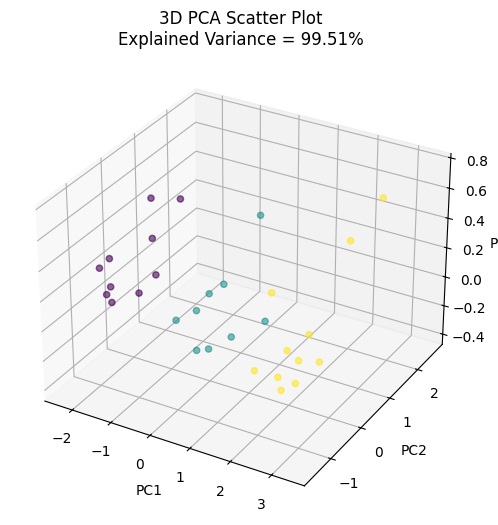

In [62]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_test_pca3[:,0],
    X_test_pca3[:,1],
    X_test_pca3[:,2],
    c=y_enc, cmap='viridis', alpha=0.6
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

var = pca.explained_variance_ratio_

ax.set_title(
    f"3D PCA Scatter Plot\n"
    f"Explained Variance = {(var[0]+var[1]+var[2])*100:.2f}%"
)

plt.show()


In [63]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_pca3, y_train)


LogisticRegression()

In [64]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred3 = clf.predict(X_test_pca3)

print("Accuracy:", accuracy_score(y_test, y_pred3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))


Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#Report Based on all 3 pca trained

In [65]:
print("Report Based on without PCA")
print("\nAccuracy:", accuracy_score(y_test, y_pred0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred0))
print("____________________________________________________________________")
print("Report Based on only 1 feature")
print("\nAccuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("____________________________________________________________________")
print("Report Based on 2 features")
print("\nAccuracy:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("____________________________________________________________________")

print("Report Based on 3 features")
print("\nAccuracy:", accuracy_score(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))




Report Based on without PCA

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
____________________________________________________________________
Report Based on only 1 feature

Accuracy: 0.9
Confusion Matrix:
 [[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]
____________________________________________________________________
Report Based on 2 features

Accuracy: 0.9
Confusion Matrix:
 [[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]
____________________________________________________________________
Report Based on 3 features

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


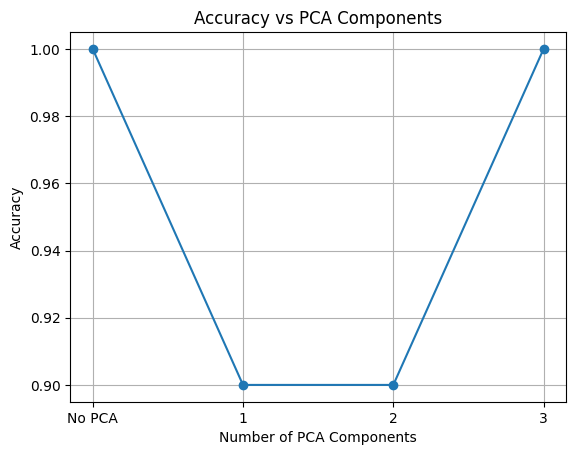

In [66]:
import matplotlib.pyplot as plt

components = ["No PCA","1","2","3"]
accuracies = [accuracy_score(y_test, y_pred0),accuracy_score(y_test, y_pred1),accuracy_score(y_test, y_pred2),accuracy_score(y_test, y_pred3)]

plt.plot(components, accuracies, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components")
plt.xticks(components)
plt.grid(True)
plt.show()
